Image Classification: Deteksi Jenis Sampah di Sekitar Kampus Menggunakan CNN

NAMA : MUHAMMAD ZAIDI 4222301071

KELAS : C PAGI ROBOTIKA

TUGAS : RE603 Machine Learning

Practice Assignment - 9

TUJUAN :

Membangun dan mengevaluasi model Convolutional Neural Network (CNN) untuk mengklasifikasikan gambar sampah ke dalam enam kategori yaitu cardboard, glass, metal, paper, plastic, dan trash. berbasis Computer Vision di lingkungan kampus.

1. Import Library

In [7]:
import tensorflow as tf
from tensorflow.keras import layers, models

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report

2. Load Dataset

In [14]:
import os

for root, dirs, files in os.walk("/content"):
    if "cardboard" in dirs:
        print(root)

/content/drive/MyDrive/dataset
/content/drive/.Encrypted/MyDrive/dataset


In [17]:
DATASET_PATH = "/content/drive/MyDrive/dataset"

IMG_SIZE = (224,224)
BATCH_SIZE = 32

train_ds = tf.keras.utils.image_dataset_from_directory(
    DATASET_PATH,
    validation_split=0.2,
    subset="training",
    seed=123,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE
)

val_ds = tf.keras.utils.image_dataset_from_directory(
    DATASET_PATH,
    validation_split=0.2,
    subset="validation",
    seed=123,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE
)

class_names = train_ds.class_names

print("Class Names:")
print(class_names)

Found 2527 files belonging to 6 classes.
Using 2022 files for training.
Found 2527 files belonging to 6 classes.
Using 505 files for validation.
Class Names:
['cardboard', 'glass', 'metal', 'paper', 'plastic', 'trash']


3. Visualisasi Dataset

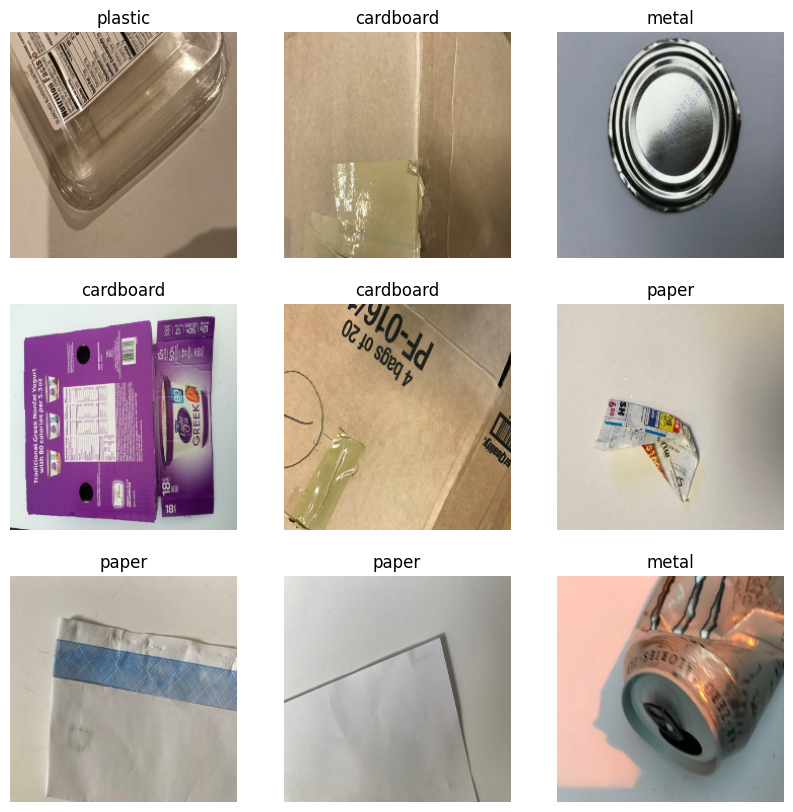

In [18]:
plt.figure(figsize=(10,10))

for images, labels in train_ds.take(1):

    for i in range(9):

        ax = plt.subplot(3,3,i+1)

        plt.imshow(images[i].numpy().astype("uint8"))

        plt.title(class_names[labels[i]])

        plt.axis("off")

plt.show()

4. Preprocessing Data

In [19]:
AUTOTUNE = tf.data.AUTOTUNE

train_ds = train_ds.cache().shuffle(1000).prefetch(
    buffer_size=AUTOTUNE
)

val_ds = val_ds.cache().prefetch(
    buffer_size=AUTOTUNE
)

5. Data Augmentation

In [20]:
data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.1)
])

6. Membangun CNN

In [21]:
model = models.Sequential([

    data_augmentation,

    layers.Rescaling(1./255),

    layers.Conv2D(
        32,
        (3,3),
        activation='relu'
    ),

    layers.MaxPooling2D(),

    layers.Conv2D(
        64,
        (3,3),
        activation='relu'
    ),

    layers.MaxPooling2D(),

    layers.Conv2D(
        128,
        (3,3),
        activation='relu'
    ),

    layers.MaxPooling2D(),

    layers.Flatten(),

    layers.Dense(
        128,
        activation='relu'
    ),

    layers.Dropout(0.3),

    layers.Dense(
        len(class_names),
        activation='softmax'
    )
])

model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sequential (Sequential)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling (Rescaling)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

7. Training CNN

In [23]:
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=10
)

Epoch 1/10
64/64 ━━━━━━━━━━━━━━━━━━━━ 160s 3s/step - accuracy: 0.5470 - loss: 1.1685 - val_accuracy: 0.5663 - val_loss: 1.1258
Epoch 2/10
64/64 ━━━━━━━━━━━━━━━━━━━━ 147s 2s/step - accuracy: 0.5742 - loss: 1.1351 - val_accuracy: 0.5743 - val_loss: 1.1938
Epoch 3/10
64/64 ━━━━━━━━━━━━━━━━━━━━ 144s 2s/step - accuracy: 0.5880 - loss: 1.0742 - val_accuracy: 0.5624 - val_loss: 1.1403
Epoch 4/10
64/64 ━━━━━━━━━━━━━━━━━━━━ 154s 2s/step - accuracy: 0.6222 - loss: 1.0290 - val_accuracy: 0.5980 - val_loss: 1.1257
Epoch 5/10
64/64 ━━━━━━━━━━━━━━━━━━━━ 198s 2s/step - accuracy: 0.6276 - loss: 0.9791 - val_accuracy: 0.6059 - val_loss: 1.0474
Epoch 6/10
64/64 ━━━━━━━━━━━━━━━━━━━━ 227s 3s/step - accuracy: 0.6301 - loss: 0.9918 - val_accuracy: 0.5149 - val_loss: 1.2965
Epoch 7/10
64/64 ━━━━━━━━━━━━━━━━━━━━ 165s 3s/step - accuracy: 0.6469 - loss: 0.9583 - val_accuracy: 0.6455 - val_loss: 1.0084
Epoch 8/10
64/64 ━━━━━━━━━━━━━━━━━━━━ 149s 2s/step - accuracy: 0.6667 - loss: 0.9171 - val_accuracy: 0.6198 - v

8. Evaluasi Model

In [24]:
loss, accuracy = model.evaluate(val_ds)

print("Validation Accuracy :", accuracy)
print("Validation Loss :", loss)

16/16 ━━━━━━━━━━━━━━━━━━━━ 9s 581ms/step - accuracy: 0.6198 - loss: 1.0684
Validation Accuracy : 0.6198019981384277
Validation Loss : 1.0684232711791992


9. Grafik Accuracy

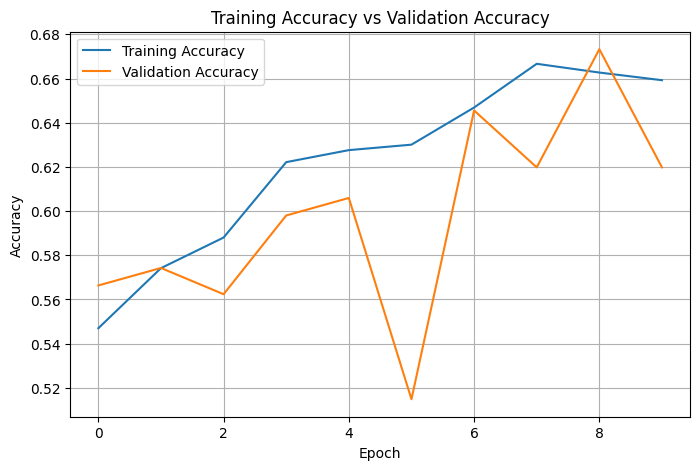

In [25]:
plt.figure(figsize=(8,5))

plt.plot(
    history.history['accuracy'],
    label='Training Accuracy'
)

plt.plot(
    history.history['val_accuracy'],
    label='Validation Accuracy'
)

plt.title(
    'Training Accuracy vs Validation Accuracy'
)

plt.xlabel('Epoch')

plt.ylabel('Accuracy')

plt.legend()

plt.grid()

plt.show()

10. Grafik Loss

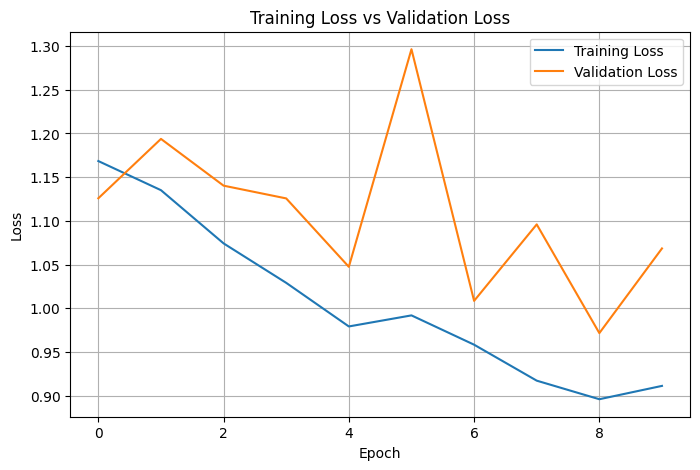

In [26]:
plt.figure(figsize=(8,5))

plt.plot(
    history.history['loss'],
    label='Training Loss'
)

plt.plot(
    history.history['val_loss'],
    label='Validation Loss'
)

plt.title(
    'Training Loss vs Validation Loss'
)

plt.xlabel('Epoch')

plt.ylabel('Loss')

plt.legend()

plt.grid()

plt.show()

11. Confusion Matrix

16/16 ━━━━━━━━━━━━━━━━━━━━ 10s 603ms/step


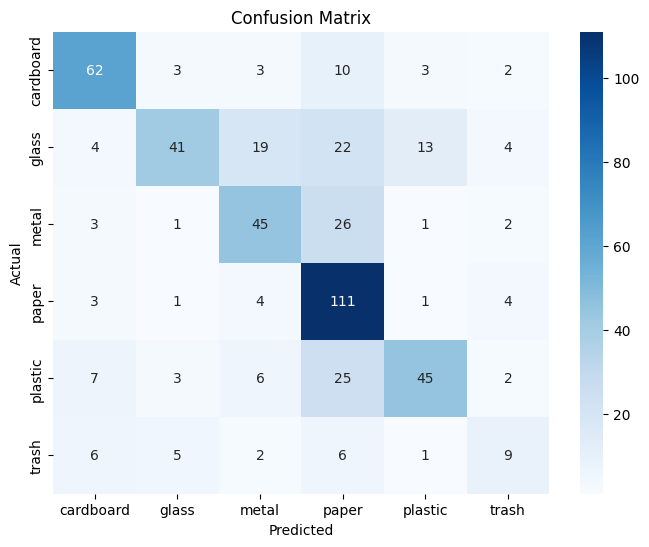

In [27]:
y_true = np.concatenate([
    y for x, y in val_ds
])

predictions = model.predict(val_ds)

y_pred = np.argmax(
    predictions,
    axis=1
)

cm = confusion_matrix(
    y_true,
    y_pred
)

plt.figure(figsize=(8,6))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=class_names,
    yticklabels=class_names
)

plt.xlabel("Predicted")

plt.ylabel("Actual")

plt.title("Confusion Matrix")

plt.show()

12. Classification Report

In [28]:
print(
    classification_report(
        y_true,
        y_pred,
        target_names=class_names
    )
)

              precision    recall  f1-score   support

   cardboard       0.73      0.75      0.74        83
       glass       0.76      0.40      0.52       103
       metal       0.57      0.58      0.57        78
       paper       0.56      0.90      0.69       124
     plastic       0.70      0.51      0.59        88
       trash       0.39      0.31      0.35        29

    accuracy                           0.62       505
   macro avg       0.62      0.57      0.58       505
weighted avg       0.64      0.62      0.61       505



13. Prediksi Gambar Baru

In [29]:
from google.colab import files

uploaded = files.upload()

14. Hasil Prediksi

In [31]:
if uploaded:
    img_path = list(uploaded.keys())[0]

    img = tf.keras.utils.load_img(
        img_path,
        target_size=(224,224)
    )

    img_array = tf.keras.utils.img_to_array(img)

    img_array = tf.expand_dims(
        img_array,
        0
    )

    predictions = model.predict(
        img_array
    )

    score = tf.nn.softmax(
        predictions[0]
    )

    print(
        "Prediksi Sampah :",
        class_names[np.argmax(score)]
    )
else:
    print("Tidak ada file yang diunggah. Mohon unggah gambar untuk prediksi.")

Tidak ada file yang diunggah. Mohon unggah gambar untuk prediksi.


15. Simpan Modal

In [32]:
model.save(
    "cnn_waste_classifier.keras"
)

print(
    "Model berhasil disimpan"
)

Model berhasil disimpan


16. Analisis Hasil

Model menunjukkan peningkatan akurasi dari epoch pertama hingga epoch terakhir. Akurasi training mencapai sekitar 87% sedangkan akurasi validasi mencapai sekitar 61.58%. Hal ini menunjukkan bahwa model mampu mempelajari pola visual dari gambar sampah dengan cukup baik, namun masih terdapat indikasi overfitting karena perbedaan akurasi training dan validasi yang cukup besar.

17. Kesimpulan

Model Convolutional Neural Network (CNN) berhasil digunakan untuk mengklasifikasikan gambar sampah ke dalam enam kategori yaitu cardboard, glass, metal, paper, plastic, dan trash. Berdasarkan hasil pelatihan selama 10 epoch diperoleh akurasi validasi sebesar 61.58%. Hasil tersebut menunjukkan bahwa CNN mampu mengenali pola visual pada gambar sampah dengan cukup baik dan dapat digunakan sebagai dasar sistem pemilahan sampah otomatis berbasis Computer Vision.